# Assignment 3: Training & Experiment Tracking

## Wo befinden wir uns im MLOps-Projekt?

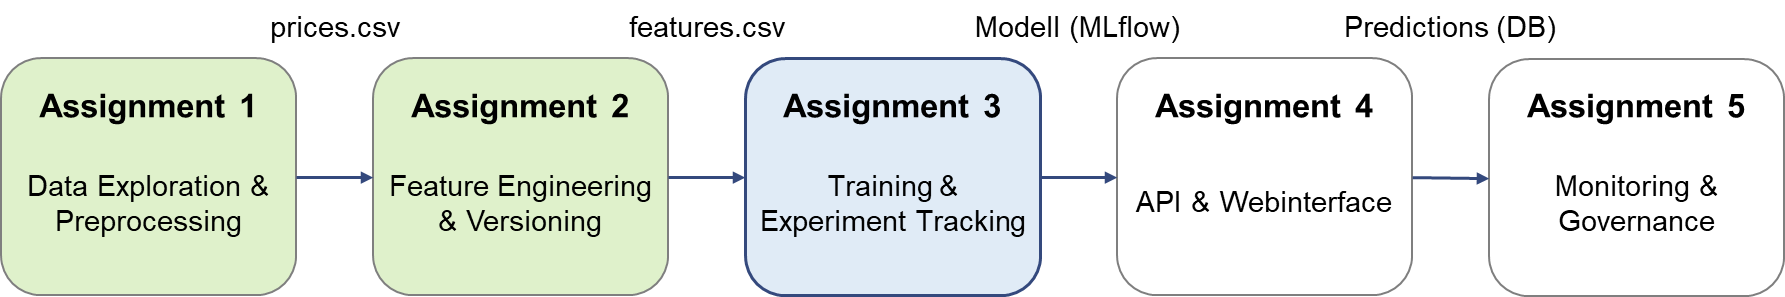

## Was passiert in diesem Notebook?

Sie trainieren ein **Regressionsmodell** auf den Feature-Daten aus A2 und loggen alles in **MLflow** – Parameter, Metriken, Feature Importance und das fertige Modell. Das Modell wird in der **MLflow Model Registry** registriert, sodass A4 (FastAPI) und A5 (Monitoring) es jederzeit laden können.

**Das zentrale Konzept: MLflow als Experiment-Tracking-System**
```
Jeder Trainingsrun erzeugt:
  ├── Parameter   (Hyperparameter des Modells)       → reproduzierbar
  ├── Metriken    (RMSE, MAE, R², MAPE)              → vergleichbar
  ├── Artefakte   (Modell, feature_importance.json)  → wiederverwendbar
  └── Model-Tag   (Versionsnummer in Registry)       → deploybar
```

**Warum temporaler Split?** Bei Zeitreihendaten würde ein zufälliger Split "in die Zukunft schauen" – das Modell würde auf Daten trainiert, die nach dem Testset liegen, und zu optimistische Metriken liefern.

**Voraussetzung:** A2 abgeschlossen (`data/processed/features.csv` vorhanden)  
**Ausgabe:** Modell in MLflow Registry  
**MLflow UI:** http://141.47.5.55:5000

---

**Funktionen zu implementieren:**
| Funktion | Beschreibung |
|---|---|
| `temporal_split()` | Train/Test-Split ohne Shuffle (zeitlich!) |
| `compute_metrics()` | RMSE, MAE, R², MAPE berechnen |
| `train_and_log()` | MLflow Experiment + Model Registry |

> ⚠️ **KRITISCH:** Temporaler Split – KEIN `shuffle=True`! Zeitreihenreihenfolge muss erhalten bleiben.

## Bewertungskriterien (17 Punkte)

| Kriterium | Punkte |
|---|---|
| Temporaler Train/Test-Split (kein Shuffle, korrektes Verhältnis) | 2 |
| MLflow Experiment Logging (Parameter, Metriken RMSE/MAE/R²/MAPE, Artefakte) | 5 |
| Modell-Vergleich & Selektion (mind. 3 Runs verglichen, Entscheidung begründet) | 5 |
| Model Registry (bestes Modell registriert, versioniert, abrufbar) | 3 |
| Dokumentation (Feature Importance geloggt, Modell-Entscheidung begründet) | 2 |
| **Gesamt** | **17** |

**Abgabe: 14.05.2026 um 23:59 Uhr**

In [ ]:
import os, sys, json, math

_cwd = os.getcwd()
PROJECT_ROOT = _cwd if os.path.exists(os.path.join(_cwd, "config.py")) \
               else os.path.abspath(os.path.join(_cwd, ".."))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# config.py setzt AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY, MLFLOW_S3_ENDPOINT_URL
# automatisch via os.environ – kein manueller Schritt nötig.
from config import GROUP_ID, MLFLOW_TRACKING_URI, DEFAULT_PARAMS, FUEL_TYPE, MINIO_ENDPOINT

params        = DEFAULT_PARAMS
train_cfg     = params["train"]
mlflow_cfg    = params["mlflow"]
features_path = os.path.join(PROJECT_ROOT, params["paths"]["processed"])

# MLflow konfigurieren + Experiment mit gruppenspezifischem Artifact-Pfad anlegen.
# Artefakte (Modell, Plots) landen in MinIO unter s3://mlflow/<GROUP_ID>/artifacts/
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
artifact_location = f"s3://mlflow/{GROUP_ID}/artifacts"
client = mlflow.MlflowClient()
try:
    client.create_experiment(mlflow_cfg["experiment_name"], artifact_location=artifact_location)
except mlflow.exceptions.MlflowException:
    pass  # Experiment existiert bereits – artifact_location bleibt erhalten
mlflow.set_experiment(mlflow_cfg["experiment_name"])

print(f"Gruppe          : {GROUP_ID}")
print(f"Fuel Type       : {FUEL_TYPE}")
print(f"Experiment Name : {mlflow_cfg['experiment_name']}")
print(f"MLflow URI      : http://141.47.5.55:5000")
print(f"Artifact-Pfad   : {artifact_location}")
print(f"Features Pfad   : {features_path}")

---
## TODO (1/4): `temporal_split()`

### Aufgabe

`temporal_split()` teilt den Feature-Datensatz zeitlich in Training- und Test-Daten auf.
Kein random shuffle – die zeitliche Reihenfolge muss erhalten bleiben.

**Fester Split:**
- **Training:** bis einschließlich 31.12.2025
- **Test:** Januar 2026 (01.01.2026 – 31.01.2026)

### Hintergrund

Bei Zeitreihen würde ein zufälliger Split "in die Zukunft schauen" – das Modell würde auf Daten
trainiert, die nach dem Testset liegen, und unrealistisch gute Metriken liefern:

```
Zeitreihe: Jan → Feb → Mär → Apr → Mai → Jun

Zufälliger Split (FALSCH):
  Train: Jan, Mär, Mai     Test: Feb, Apr, Jun
  ❌ Das Modell lernt aus der "Zukunft" (Mai) und wird an
     der "Vergangenheit" (Feb) gemessen → unrealistisch!

Temporaler Split (RICHTIG):
  Train: bis Dez 2025      Test: Jan 2026
  ✓ Das Modell lernt nur aus der Vergangenheit und wird
    an echten "zukünftigen" Daten gemessen.
```

**Warum Test = Januar 2026?** Der reale Preisanstieg begann erst im März 2026.
Januar ist daher eine saubere, ungestörte Testperiode – bevor der Drift einsetzt.

### Hinweise
- `datetime`-Spalte als `pd.Timestamp` parsen
- `train_end_date` aus `params["train"]["train_end_date"]` lesen
- Feature-Spalten: alle außer `datetime`, `{FUEL_TYPE}_price` und `target_col`
- Feature-Matrix `X` und Zielvektor `y` als NumPy-Arrays (`.values`)
- Rückgabe: `X_train, X_test, y_train, y_test, feature_cols`

**Dokumentation:**
- [pandas Boolean Indexing](https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing) – `df[df["datetime"] <= train_end]`
- [DataFrame.values](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.values.html) – DataFrame → NumPy-Array (für scikit-learn)

### Bewertungskriterien

**Pflicht:**
- Datums-basierter Split: Training ≤ 31.12.2025, Test = Januar 2026
- Feature-Spalten korrekt selektiert (ohne `datetime`, `{FUEL_TYPE}_price`, `target_col`)
- Feature-Matrix und Zielvektor als NumPy-Arrays
- Rückgabe aller fünf Werte (inkl. `feature_cols` für MLflow-Logging)

**Optional (+):**
- Kommentar oder Markdown-Erklärung: warum führt `shuffle=True` zu Data Leakage bei Zeitreihen?
- Visualisierung des Splits (z.B. Zeitreihen-Plot Trainings- vs. Testperiode) als zusätzliche Zelle

In [ ]:
def temporal_split(df: pd.DataFrame, target_col: str):
    """
    Datums-basierter Train/Test-Split ohne Shuffle.

    Training: bis einschließlich 31.12.2025
    Test:     Januar 2026 (01.01.2026 – 31.01.2026)

    Args:
        df:         features.csv als DataFrame (Ausgabe von A2)
        target_col: Name der Zielvariable, z.B. "e5_price_next_hour"

    Returns:
        X_train (np.ndarray), X_test (np.ndarray),
        y_train (np.ndarray), y_test (np.ndarray),
        feature_cols (list[str])  ← Spaltennamen der Features (für MLflow-Logging)

    ⚠️ KEIN shuffle! Zeitreihenreihenfolge muss erhalten bleiben.
    """
    # Schritt 1: datetime-Spalte parsen + Split-Grenzen als pd.Timestamp setzen
    #            train_end = pd.Timestamp("2025-12-31 23:59:59")
    #            test_end  = pd.Timestamp("2026-01-31 23:59:59")

    # Schritt 2: Train-Maske und Test-Maske erstellen (Boolean Indexing)

    # Schritt 3: Feature-Spalten bestimmen (alle außer datetime, {FUEL_TYPE}_price, target_col)

    # Schritt 4: X_train, X_test, y_train, y_test als NumPy-Arrays extrahieren

    # Schritt 5: Alle fünf Werte zurückgeben

    raise NotImplementedError("TODO (1/4): temporal_split implementieren")

# Test
df = pd.read_csv(features_path)
X_train, X_test, y_train, y_test, feature_cols = temporal_split(
    df, target_col=params["features"]["target_column"]
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}")
print(f"Feature-Namen: {feature_cols}")

---
## TODO (2/4): `compute_metrics()`

### Aufgabe

`compute_metrics()` berechnet standardisierte Regressions-Metriken für die Modellbewertung.
Sie wird für Trainings- und Testdaten aufgerufen und muss konsistent sein – für Production-Monitoring
in A4 werden dieselben Metriken erwartet.

### Hintergrund

Die wichtigsten Metriken im Überblick:

- **RMSE** (Root Mean Squared Error): Bestraft große Fehler stärker. Gut: 0.001–0.005 EUR/L
- **MAE** (Mean Absolute Error): Robuster gegenüber Ausreißern. Einfach interpretierbar: "Durchschnittlicher Fehler in EUR/L"
- **R²** (Bestimmtheitsmaß): 1.0 = perfekte Vorhersage. Erwartet: ≥ 0.99 (lag_1h erklärt fast alles)
- **MAPE** (Mean Absolute Percentage Error): Relativer Fehler in %. Nullen in `y_true` ausschließen!

### Hinweise
- `mean_squared_error`, `mean_absolute_error`, `r2_score` aus `sklearn.metrics`
- RMSE = `math.sqrt(mean_squared_error(...))`
- MAPE: Nullen in `y_true` mit einer Boolean-Maske ausschließen (Division by Zero!)
- Alle Werte auf 6 Nachkommastellen runden (`round(..., 6)`)

**Dokumentation:**
- [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) – `mean_squared_error`, `mean_absolute_error`, `r2_score`
- [math.sqrt](https://docs.python.org/3/library/math.html#math.sqrt) – Quadratwurzel für RMSE
- [NumPy Boolean Indexing](https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing) – `y_true[mask]` filtert Nullen für MAPE

In [ ]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Berechnet Regressions-Metriken für Modellbewertung.

    Args:
        y_true: Echte Zielwerte (z.B. tatsächliche E5-Preise)
        y_pred: Vorhergesagte Werte (z.B. Modellvorhersagen)

    Returns:
        dict mit Keys:
            rmse  (float, 6 Stellen) – Root Mean Squared Error
            mae   (float, 6 Stellen) – Mean Absolute Error
            r2    (float, 6 Stellen) – R²-Score (1.0 = perfekt)
            mape  (float, 4 Stellen) – Mean Absolute Percentage Error in %

    Interface → train_and_log():
        Wird für train_metrics und test_metrics aufgerufen.
        Ergebnis-Dict wird direkt an mlflow.log_metrics() übergeben.
    """
    # Schritt 1: RMSE berechnen

    # Schritt 2: MAE berechnen

    # Schritt 3: R²-Score berechnen

    # Schritt 4: MAPE berechnen (Nullen in y_true ausschließen → Division by Zero)

    raise NotImplementedError("TODO (2/4): compute_metrics implementieren")

# Test mit Dummy-Werten
y_dummy = np.array([1.7, 1.8, 1.75, 1.82])
metrics_test = compute_metrics(y_dummy, y_dummy + 0.01)
print("Metriken (Dummy-Test):", metrics_test)

---
## TODO (3/4): `train_and_log(model_params)`

### Aufgabe

`train_and_log()` trainiert ein RandomForest-Modell mit den übergebenen Parametern und
loggt alles (Parameter, Metriken, Modell, Feature Importance) in MLflow.

Die Funktion akzeptiert `model_params` als Argument – so können Sie dieselbe Funktion
mehrfach mit unterschiedlichen Hyperparameter-Konfigurationen aufrufen und die Ergebnisse
direkt in MLflow vergleichen.

### Hintergrund

```
train_and_log(model_params):
  deps: features.csv (von A2), MLFLOW_TRACKING_URI (von config.py)
  outs: MLflow Run (Metriken + Modell in Registry)
```

### Hinweise
- `model_params` direkt an `RandomForestRegressor(**model_params)` übergeben
- MLflow Run mit `mlflow.start_run()` als Context Manager starten
- Modell registrieren mit `mlflow.sklearn.log_model(..., registered_model_name=...)`
- Feature Importance als JSON-Artefakt loggen

**Dokumentation:**
- [mlflow.start_run](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.start_run)
- [mlflow.sklearn.log_model](https://mlflow.org/docs/latest/python_api/mlflow.sklearn.html)
- [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

In [ ]:
def train_and_log(model_params: dict) -> str:
    """
    Trainiert ein Regressionsmodell mit den übergebenen Parametern und loggt alles in MLflow.

    Args:
        model_params: Hyperparameter für RandomForestRegressor
                      z.B. {"n_estimators": 100, "max_depth": 10, "random_state": 42}

    Returns:
        run_id (str) – MLflow Run ID des Trainingsruns

    Seiteneffekte:
        - MLflow Experiment + Run erstellt (sichtbar unter http://141.47.5.55:5000)
        - Modell in MLflow Model Registry registriert als mlflow_cfg["model_name"]

    Interface ← A2: Liest features.csv (über features_path)
    Interface → A4: Modell in Registry wird von predict.py geladen
    Interface → A5: Drift-Analyse nutzt Modell aus Registry
    """
    # Schritt 1: features.csv laden + temporal_split aufrufen
    #            (Training: bis 31.12.2025, Test: Januar 2026)

    # Schritt 2: MLflow Tracking URI + Experiment setzen

    # Schritt 3: MLflow Run starten + model_params loggen

    # Schritt 4: Regressionsmodell trainieren (RandomForestRegressor mit model_params)

    # Schritt 5: Metriken für Train + Test berechnen und in MLflow loggen

    # Schritt 6: Modell in Registry registrieren

    # Schritt 7: Feature Importance als JSON-Artefakt loggen

    # Schritt 8: run_id zurückgeben

    raise NotImplementedError("TODO (3/4): train_and_log implementieren")

---
## Modell-Vergleich & Selektion (Pflicht – 5 Punkte)

### Aufgabe
Trainieren Sie **mindestens 3 verschiedene Konfigurationen** und vergleichen Sie sie in MLflow.
Wählen Sie das beste Modell und begründen Sie Ihre Entscheidung.

### Was zu tun ist
1. Rufen Sie `train_and_log(model_params)` dreimal mit unterschiedlichen Parametern auf
2. Öffnen Sie die MLflow UI: **http://141.47.5.55:5000**
3. Vergleichen Sie die Runs im Tab „Experiments" → Experiment `{FUEL_TYPE}-preis-<Ihre-ID>`
4. Dokumentieren Sie unten, welches Modell Sie wählen und warum

### Bewertungskriterien
- Mindestens 3 Runs im MLflow Experiment nachweisbar
- Verschiedene Konfigurationen (nicht nur copy-paste mit gleichen Parametern)
- Begründung der Modell-Entscheidung in der Markdown-Zelle unten

In [ ]:
# Experiment 1: Basis-Konfiguration
params_1 = {"n_estimators": 100, "max_depth": 10, "min_samples_split": 2, "random_state": 42}
run_id_1 = train_and_log(params_1)
print(f"Run 1: {run_id_1}")

In [ ]:
# Experiment 2: Mehr Bäume, tiefere Tiefe
params_2 = {"n_estimators": 200, "max_depth": 15, "min_samples_split": 2, "random_state": 42}
run_id_2 = train_and_log(params_2)
print(f"Run 2: {run_id_2}")

In [ ]:
# Experiment 3: Eigene Variation – passen Sie die Parameter nach eigenem Ermessen an
params_3 = {"n_estimators": 150, "max_depth": 8, "min_samples_split": 5, "random_state": 42}
run_id_3 = train_and_log(params_3)
print(f"Run 3: {run_id_3}")

## Modell-Entscheidung: Begründung

*Füllen Sie diese Zelle nach dem Vergleich der Experimente aus:*

**Gewähltes Modell:** Run ID `...` (Experiment N)

**Begründung:**
- Test-RMSE: ...
- Test-R²: ...
- Im Vergleich zu den anderen Konfigurationen: ...

---
## Metriken in MLflow prüfen

Alle Metriken werden direkt in MLflow geloggt – kein separater Export nötig.

Öffnen Sie die MLflow UI und überprüfen Sie Ihren Run:

**http://141.47.5.55:5000** → Experiment `{FUEL_TYPE}-preis-<Ihre-ID>` → Run anklicken

Folgende Metriken sollten im Run sichtbar sein:

| Metrik | Bedeutung |
|---|---|
| `train_rmse` | Root Mean Squared Error auf Trainingsdaten |
| `train_mae` | Mean Absolute Error auf Trainingsdaten |
| `train_r2` | R²-Score auf Trainingsdaten |
| `train_mape` | Mean Absolute Percentage Error auf Trainingsdaten |
| `test_rmse` | Root Mean Squared Error auf Testdaten *(wichtigste Metrik!)* |
| `test_mae` | Mean Absolute Error auf Testdaten |
| `test_r2` | R²-Score auf Testdaten |
| `test_mape` | Mean Absolute Percentage Error auf Testdaten |

**Tipp:** Im Tab „Compare Runs" können Sie mehrere Runs direkt gegenüberstellen und die Metriken als Chart visualisieren.

---
## Ergebnis prüfen

- **MLflow UI:** `http://141.47.5.55:5000` → Experiment `{FUEL_TYPE}-preis-<Ihre-ID>` → Run anklicken
- **Model Registry:** Tab "Models" → `{FUEL_TYPE}-preis-regressor-<Ihre-ID>`

### Hinweis: Energiekrise März 2026

Anfang März 2026 kam es durch einen geopolitischen Konflikt zu einem abrupten Preisanstieg beim Kraftstoff (+25–30% innerhalb weniger Tage). Dieser **Concept Drift** beeinflusst das Modell:

- Liegt Ihr Test-Set im Zeitraum **März 2026 oder später**, wird das Modell auf einem Preismuster trainiert, das sich stark vom Testmuster unterscheidet.
- In diesem Fall ist ein **R² < 0.9** normal und kein Implementierungsfehler – die naive Baseline (nächste Stunde = aktuelle Stunde) erreicht selbst nur R² ≈ 0.79.
- **Experiment:** Verschieben Sie den `test_size`-Parameter (z.B. auf 0.1 statt 0.2), um die Driftperiode aus dem Test-Set herauszuhalten. Beobachten Sie, wie sich R² verändert.
- **Lernziel:** Genau dieses Phänomen – Data Drift in Produktion – analysieren wir in **A5 (Monitoring)**.

Weiter mit: **A4_API.ipynb**

In [ ]:
# ── Schritt-für-Schritt Validierung (vor der Abgabe ausführen) ────────────
import mlflow
from config import MLFLOW_TRACKING_URI, DEFAULT_PARAMS

# 1. MLflow: Mindestens 3 Runs?
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.MlflowClient()
exp = client.get_experiment_by_name(DEFAULT_PARAMS["mlflow"]["experiment_name"])
if exp:
    runs = client.search_runs([exp.experiment_id], filter_string="status = 'FINISHED'")
    n = len(runs)
    status = "OK" if n >= 3 else "FEHLER"
    print(f"{status}: {n} abgeschlossene Runs (mindestens 3 benötigt)")
else:
    print("FEHLER: MLflow-Experiment nicht gefunden – train_and_log() ausführen")

# 2. Modell in Registry?
model_name = DEFAULT_PARAMS["mlflow"]["model_name"]
try:
    versions = client.get_latest_versions(model_name)
    print(f"OK: Modell '{model_name}' in Registry (Version {versions[0].version})")
except:
    print(f"FEHLER: Modell '{model_name}' nicht in Registry – registered_model_name setzen")

---
## DVC: `train`-Stage aktivieren

`dvc.yaml` enthält die `train`-Stage bereits als Kommentar – Sie müssen sie nur einkommentieren.

**Ihre Aufgabe:** Öffnen Sie `dvc.yaml` und entfernen Sie die `#`-Zeichen vor der `train`-Stage:

```yaml
stages:
  # ... ingest und preprocess bereits ausgefüllt (A2) ...

  train:
    cmd: jupyter nbconvert --to notebook --execute --inplace notebooks/A3_Training.ipynb
    deps:
      - notebooks/A3_Training.ipynb
      - config.py
      - data/processed/features.csv
```

> **Hinweis:** Die `train`-Stage hat keine `outs` – das Modell landet direkt in der MLflow Registry,
> nicht als lokale Datei. DVC trackt hier nur die Abhängigkeiten.

**Danach:**
```bash
dvc repro train          # führt A3_Training.ipynb aus
git add dvc.yaml dvc.lock notebooks/A3_Training.ipynb
git commit -m "A3: train-Stage in dvc.yaml aktiviert"
git push
```

In [ ]:
import subprocess

print("=== Pipeline-Status ===")
result = subprocess.run(["dvc", "status"], capture_output=True, text=True)
print(result.stdout if result.stdout.strip() else "Alles aktuell.")

print("=== Abhängigkeitsgraph ===")
result = subprocess.run(["dvc", "dag"], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else result.stderr)

---
**Abgabe: 14.05.2026 um 23:59 Uhr**

**Checkliste:**
- [ ] Mindestens 3 MLflow Runs unter Experiment `{FUEL_TYPE}-preis-<Ihre-ID>` sichtbar
- [ ] Alle 8 Metriken (train/test × RMSE/MAE/R²/MAPE) in jedem Run geloggt
- [ ] Bestes Modell in Model Registry registriert als `{FUEL_TYPE}-preis-regressor-<Ihre-ID>`
- [ ] Feature Importance als JSON-Artefakt im Run vorhanden
- [ ] Modell-Entscheidung begründet (Markdown-Zelle ausgefüllt)

Weiter mit: **A4_API.ipynb**